# GTSRB Traffic-Sign Classification with a Small CNN

43-class single-image classification on the
[German Traffic Sign Recognition Benchmark (GTSRB)](https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign).

**Constraint:** if a dataset is larger than about 10–20,000 samples, use a subset.
Training uses a balanced subset of **19,995** images (465 per class) instead of the full 39,209 training images.

The model is a small PyTorch CNN. The notebook runs locally and on Google Colab (GPU is used when available).


## 1. Dataset check

GTSRB is a multi-class image dataset of German traffic signs:

- More than 40 classes (here: **43**)
- Training split: **39,209** labelled images
- Official test split: **12,630** labelled images
- Image sizes vary (median 43 px); every image is resized to **32x32** RGB

The files come from Kaggle via `kagglehub`. A valid download contains `Train/`, `Test/`, `Meta/`, and the matching CSV files.

Both CSVs also carry a **region of interest** (`Roi.X1`, `Roi.Y1`, `Roi.X2`, `Roi.Y2`): the bounding box of the sign
inside the image. We use it in section 5.


In [1]:
from pathlib import Path

import kagglehub

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Colab has no ~/.kaggle credentials; this prompts for username and API key.
    kagglehub.login()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps

DATASET_HANDLE = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
SAMPLES_PER_CLASS = 465  # 465 * 43 = 19,995 (just under 20,000)
SEED = 42
IMG_SIZE = 32
NUM_CLASSES = 43
NUM_EPOCHS = 30
BATCH_SIZE = 64
MAX_ROTATION_DEG = 10
ROI_PAD = 0.10  # keep a small margin around the annotated sign box
VAL_TRACK_FRACTION = 0.2

CLASS_NAMES = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing (vehicles over 3.5 t)",
    11: "Right-of-way at intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 t prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing (vehicles over 3.5 t)",
}

data_path = Path(kagglehub.dataset_download(DATASET_HANDLE))
train_df = pd.read_csv(data_path / "Train.csv")
test_df = pd.read_csv(data_path / "Test.csv")

print("Running on Colab:", IN_COLAB)
print("Dataset path:", data_path)
print("Folders:", sorted(p.name for p in data_path.iterdir()))
print(f"Train: {len(train_df)} images, {train_df['ClassId'].nunique()} classes")
print(f"Test:  {len(test_df)} images, {test_df['ClassId'].nunique()} classes")
train_df.head()


Running on Colab: False
Dataset path: C:\Users\timho\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1
Folders: ['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']
Train: 39209 images, 43 classes
Test:  12630 images, 43 classes


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


## 2. Class imbalance

The training set is **not balanced**. Common speed-limit and priority signs appear thousands of times; rare signs
(20 km/h, dangerous curve left, go straight or left) have only **210** images.

If we trained on all 39k images, the model would mostly see frequent classes. Accuracy could look high while rare
(and safety-relevant) signs stay weak.


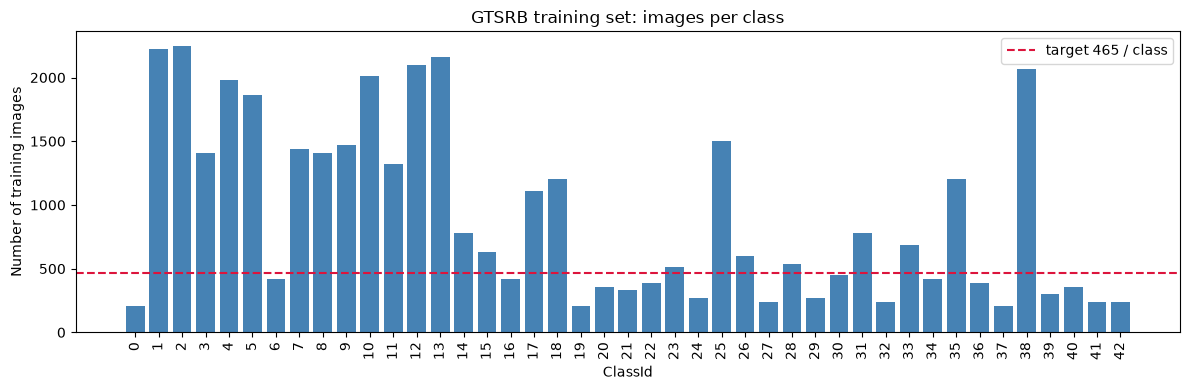

Min class size: 210
Max class size: 2250
Mean class size: 911.8
Classes below 465: 19
Balanced 20k target: 465 x 43 = 19995


In [2]:
counts = train_df["ClassId"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(counts.index.astype(str), counts.values, color="steelblue")
ax.axhline(SAMPLES_PER_CLASS, color="crimson", linestyle="--", label=f"target {SAMPLES_PER_CLASS} / class")
ax.set_xlabel("ClassId")
ax.set_ylabel("Number of training images")
ax.set_title("GTSRB training set: images per class")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Min class size: {int(counts.min())}")
print(f"Max class size: {int(counts.max())}")
print(f"Mean class size: {counts.mean():.1f}")
print(f"Classes below {SAMPLES_PER_CLASS}: {(counts < SAMPLES_PER_CLASS).sum()}")
print(f"Balanced 20k target: {SAMPLES_PER_CLASS} x {NUM_CLASSES} = {SAMPLES_PER_CLASS * NUM_CLASSES}")


## 3. The tracks: why a random validation split is wrong

GTSRB was not collected as independent photos. Each physical sign was **filmed from a moving car**, so every sign
contributes a **track of 30 consecutive frames** that differ only slightly in distance and angle.

The filename encodes this. `Train/20/00020_00000_00000.png` means `ClassId_TrackId_FrameId`.

A random per-image split therefore puts frames of the **same physical sign** into training and validation at the
same time. The model can simply memorise that sign and still score well on validation. The next cell measures how
bad this is for the naive split.


In [3]:
from sklearn.model_selection import train_test_split


def add_track_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Split the GTSRB filename ClassId_TrackId_FrameId into columns."""
    stem = df["Path"].str.rsplit("/", n=1).str[-1].str.replace(".png", "", regex=False)
    parts = stem.str.split("_")
    out = df.copy()
    out["TrackId"] = parts.str[1].astype(int)
    out["FrameId"] = parts.str[2].astype(int)
    return out


train_df = add_track_columns(train_df)

tracks_per_class = train_df.groupby("ClassId")["TrackId"].nunique()
frames_per_track = train_df.groupby(["ClassId", "TrackId"]).size()
print(f"Total tracks: {train_df.groupby(['ClassId', 'TrackId']).ngroups}")
print(f"Frames per track: min {frames_per_track.min()}, max {frames_per_track.max()}")
print(f"Tracks per class: min {tracks_per_class.min()}, max {tracks_per_class.max()}")

# How much would a naive per-image split leak?
naive_train, naive_val = train_test_split(
    train_df, test_size=0.2, stratify=train_df["ClassId"], random_state=SEED
)
train_track_keys = set(zip(naive_train["ClassId"], naive_train["TrackId"]))
val_track_keys = list(zip(naive_val["ClassId"], naive_val["TrackId"]))
leaked = sum(k in train_track_keys for k in val_track_keys)
print()
print(f"Naive random split: {leaked} of {len(val_track_keys)} validation images "
      f"({100 * leaked / len(val_track_keys):.1f}%) come from a track that is also in training.")


Total tracks: 1307
Frames per track: min 29, max 30
Tracks per class: min 7, max 75

Naive random split: 7842 of 7842 validation images (100.0%) come from a track that is also in training.


### Track-aware split

We hold out **whole tracks**, so a physical sign is either fully in training or fully in validation, never both.
About 20 percent of the tracks per class go to validation.

The rarest classes have only 7 tracks, so they keep 6 tracks for training and contribute 1 track to validation.
That is coarse but honest.

Validation is built from **real images only** and is never used for training.


In [4]:
def split_by_track(df: pd.DataFrame, val_fraction: float, seed: int):
    """Hold out whole tracks per class so no physical sign appears on both sides."""
    rng = np.random.default_rng(seed)
    val_keys = set()
    for class_id, group in df.groupby("ClassId"):
        tracks = np.sort(group["TrackId"].unique())
        n_val = max(1, int(round(len(tracks) * val_fraction)))
        for track in rng.choice(tracks, size=n_val, replace=False):
            val_keys.add((int(class_id), int(track)))

    keys = list(zip(df["ClassId"], df["TrackId"]))
    is_val = np.fromiter((k in val_keys for k in keys), dtype=bool, count=len(df))
    return df[~is_val].copy(), df[is_val].copy()


train_pool, val_pool = split_by_track(train_df, VAL_TRACK_FRACTION, SEED)

train_keys = set(zip(train_pool["ClassId"], train_pool["TrackId"]))
val_keys = set(zip(val_pool["ClassId"], val_pool["TrackId"]))
assert not (train_keys & val_keys), "a track ended up on both sides"

print(f"Training pool:   {len(train_pool)} images from {len(train_keys)} tracks")
print(f"Validation pool: {len(val_pool)} images from {len(val_keys)} tracks")
print(f"Overlapping tracks: {len(train_keys & val_keys)}")
print(f"Classes in validation: {val_pool['ClassId'].nunique()} / {NUM_CLASSES}")


Training pool:   31379 images from 1046 tracks
Validation pool: 7830 images from 261 tracks
Overlapping tracks: 0
Classes in validation: 43 / 43


## 4. Subset strategy: 465 images per class

Assignment limit: use a subset when the dataset is larger than **10-20,000** samples. We aim at the upper end so the
CNN still sees enough variety: `465 x 43 = 19,995` training samples.

The subset is drawn from the **training tracks only**:

1. Class has at least 465 images available: sample 465 **distinct** images (seed 42).
2. Class has fewer: take all of them, then **repeat** rows until 465. A repeated row is a different image every
   epoch because the augmentation runs on the fly (section 5).

We keep a `Repeated` flag so the notebook can report how much of each class is genuinely distinct. This matters for
the honest reading of the results: class 27 (Pedestrians) is built from only 8 physical signs, and no augmentation
can invent a ninth.


In [5]:
def build_balanced_subset(df: pd.DataFrame, n_per_class: int, seed: int) -> pd.DataFrame:
    """Exactly n_per_class rows per class, repeating rows only where images are missing."""
    rng = np.random.default_rng(seed)
    parts = []
    for _, group in df.groupby("ClassId"):
        group = group.reset_index(drop=True)
        if len(group) >= n_per_class:
            picked = group.iloc[rng.choice(len(group), size=n_per_class, replace=False)].copy()
            picked["Repeated"] = False
        else:
            n_extra = n_per_class - len(group)
            extra = group.iloc[rng.choice(len(group), size=n_extra, replace=True)]
            picked = pd.concat([group, extra], ignore_index=True)
            picked["Repeated"] = [False] * len(group) + [True] * n_extra
        parts.append(picked)
    return pd.concat(parts, ignore_index=True).reset_index(drop=True)


subset_df = build_balanced_subset(train_pool, SAMPLES_PER_CLASS, SEED)

assert len(subset_df) == SAMPLES_PER_CLASS * NUM_CLASSES
assert subset_df["ClassId"].nunique() == NUM_CLASSES
assert (subset_df["ClassId"].value_counts() == SAMPLES_PER_CLASS).all()

distinct = subset_df[~subset_df["Repeated"]].groupby("ClassId").size()
print(f"Training subset: {len(subset_df)} rows, {SAMPLES_PER_CLASS} per class")
print(f"Repeated rows: {int(subset_df['Repeated'].sum())} "
      f"({100 * subset_df['Repeated'].mean():.1f}%)")
print(f"Classes that needed repeats: {int((distinct < SAMPLES_PER_CLASS).sum())}")
print()
print("Classes with the fewest distinct images:")
for class_id, n in distinct.sort_values().head(5).items():
    n_tracks = train_pool[train_pool["ClassId"] == class_id]["TrackId"].nunique()
    print(f"  {class_id:>2} {CLASS_NAMES[class_id]:<38} {n:>4} distinct images from {n_tracks} physical signs")
print()
print("Subset checks passed: 43 classes, 465 rows each, 19,995 total, no validation track inside.")


Training subset: 19995 rows, 465 per class


Repeated rows: 4185 (20.9%)
Classes that needed repeats: 21

Classes with the fewest distinct images:
   0 Speed limit 20 km/h                     180 distinct images from 6 physical signs
  19 Dangerous curve to the left             180 distinct images from 6 physical signs
  27 Pedestrians                             180 distinct images from 6 physical signs
  32 End of all speed and passing limits     180 distinct images from 6 physical signs
  41 End of no passing                       180 distinct images from 6 physical signs

Subset checks passed: 43 classes, 465 rows each, 19,995 total, no validation track inside.


### Figures: balanced subset composition

The plots below show why rare classes need extra samples, how we reach 465 rows per class,
and that oversampling still rests on few physical signs.


In [ ]:
# Figures: before/after balancing and original vs repeated rows
before = train_df["ClassId"].value_counts().sort_index()
after = subset_df["ClassId"].value_counts().sort_index()
distinct = subset_df[~subset_df["Repeated"]].groupby("ClassId").size().reindex(range(NUM_CLASSES), fill_value=0)
repeated = subset_df[subset_df["Repeated"]].groupby("ClassId").size().reindex(range(NUM_CLASSES), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(NUM_CLASSES)
width = 0.42
axes[0].bar(x - width / 2, before.values, width, label="Original train", color="steelblue")
axes[0].bar(x + width / 2, after.values, width, label="Balanced subset", color="seagreen")
axes[0].axhline(SAMPLES_PER_CLASS, color="crimson", linestyle="--", linewidth=1.2, label="target 465")
axes[0].set_title("Before / after balancing")
axes[0].set_xlabel("ClassId")
axes[0].set_ylabel("Images")
axes[0].set_xticks(x[::4])
axes[0].legend(fontsize=8)

axes[1].bar(x, distinct.values, color="steelblue", label="Distinct originals")
axes[1].bar(x, repeated.values, bottom=distinct.values, color="darkorange", label="Repeated rows")
axes[1].axhline(SAMPLES_PER_CLASS, color="black", linestyle="--", linewidth=1, alpha=0.7)
axes[1].set_title("How minority classes are filled")
axes[1].set_xlabel("ClassId")
axes[1].set_ylabel("Rows in subset")
axes[1].set_xticks(x[::4])
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

n_rep = int(subset_df["Repeated"].sum())
n_orig = len(subset_df) - n_rep
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].pie(
    [n_orig, n_rep],
    labels=["Distinct originals", "Repeated rows"],
    colors=["steelblue", "darkorange"],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
)
axes[0].set_title(f"Subset composition ({len(subset_df):,} rows)")

tracks = train_pool.groupby("ClassId")["TrackId"].nunique()
rare = distinct.sort_values().head(10).index.tolist()
y = np.arange(len(rare))
axes[1].barh(y, [distinct[c] for c in rare], color="steelblue", label="Distinct")
axes[1].barh(
    y,
    [repeated[c] for c in rare],
    left=[distinct[c] for c in rare],
    color="darkorange",
    label="Repeated",
)
for i, c in enumerate(rare):
    axes[1].text(470, i, f"{tracks[c]} tracks", va="center", fontsize=8)
axes[1].set_yticks(y)
axes[1].set_yticklabels([f"{c}: {CLASS_NAMES[c]}" for c in rare], fontsize=8)
axes[1].set_xlim(0, 620)
axes[1].invert_yaxis()
axes[1].set_title("Rare classes: few physical signs")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# Repeat multiplicity for the scarcest pedestrian class
sub27 = subset_df[subset_df["ClassId"] == 27]
mult = sub27["Path"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(mult.values, bins=range(1, mult.max() + 2), color="slateblue", edgecolor="white", align="left")
ax.set_xlabel("Times the same original image appears in the subset")
ax.set_ylabel("Number of original images")
ax.set_title(f"Class 27 ({CLASS_NAMES[27]}): oversampling multiplies viewpoints, not new signs")
ax.set_xticks(range(1, mult.max() + 1))
plt.tight_layout()
plt.show()


## 5. Preprocessing and sign-safe augmentation

### Deterministic preprocessing (train, validation and test alike)

1. **Crop to the ROI box** with a 10 percent margin. The sign covers only about 75 percent of the image width, so
   roughly 13 percent of each side is background. Cropping puts the sign across the full frame.
   The median image is 43 px wide, of which the sign is about 32 px, so cropping and resizing to 32x32 is close to
   **native sampling** rather than upscaling.
2. **Autocontrast** to normalise illumination. GTSRB contains near-black frames; stretching each image to the full
   range makes the pictogram visible. This is deterministic preprocessing, not augmentation, so it is applied to
   test images too.
3. Resize to 32x32 and normalise with the dataset channel mean and standard deviation.

### Sign-safe augmentation (training only)

Traffic signs are **symbols with a legal meaning**. Transforms that are fine for photos of animals can change the
class:

- **Horizontal flip:** "turn left" becomes "turn right", "keep left" becomes "keep right".
- **Large rotation:** a warning triangle can look like a yield sign; digits such as 6 and 9 become ambiguous.

**Allowed:** brightness, contrast and saturation jitter, small Gaussian noise, small translation and zoom, and
rotation of at most **10 degrees**.

**Forbidden:** any flip, rotation beyond 10 degrees, elastic warps.

All geometry lives in a **single `RandomAffine`**, so the 10 degree cap is applied exactly once per image. The
augmentation runs on the fly, which means a repeated row is a fresh variant in every epoch instead of a frozen file
on disk.


In [6]:
import torch
from torchvision import transforms


def load_prepared(path: Path, roi) -> Image.Image:
    """Crop to the annotated sign box with a small margin, then stretch the contrast."""
    img = Image.open(path).convert("RGB")
    x1, y1, x2, y2 = (int(v) for v in roi)
    pad_x = int(round((x2 - x1) * ROI_PAD))
    pad_y = int(round((y2 - y1) * ROI_PAD))
    box = (
        max(0, x1 - pad_x),
        max(0, y1 - pad_y),
        min(img.width, x2 + pad_x),
        min(img.height, y2 + pad_y),
    )
    if box[2] > box[0] and box[3] > box[1]:
        img = img.crop(box)
    return ImageOps.autocontrast(img)


class AddGaussianNoise:
    """Sensor noise on the tensor, applied before normalisation."""

    def __init__(self, max_std: float = 0.05):
        self.max_std = max_std

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        std = float(torch.empty(1).uniform_(0.0, self.max_std))
        return torch.clamp(tensor + torch.randn_like(tensor) * std, 0.0, 1.0)


ROI_COLS = ["Roi.X1", "Roi.Y1", "Roi.X2", "Roi.Y2"]

# Channel statistics measured on a sample of the prepared training subset.
stat_sample = subset_df.sample(n=2000, random_state=SEED)
pixels = []
for _, row in stat_sample.iterrows():
    img = load_prepared(data_path / row["Path"], row[ROI_COLS]).resize((IMG_SIZE, IMG_SIZE))
    pixels.append(np.asarray(img, dtype=np.float32) / 255.0)
pixels = np.stack(pixels)
CHANNEL_MEAN = pixels.mean(axis=(0, 1, 2)).tolist()
CHANNEL_STD = pixels.std(axis=(0, 1, 2)).tolist()
del pixels

print("Channel mean:", [round(v, 4) for v in CHANNEL_MEAN])
print("Channel std: ", [round(v, 4) for v in CHANNEL_STD])

train_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
        # One affine pass: rotation stays within +/- MAX_ROTATION_DEG, no flip.
        transforms.RandomAffine(
            degrees=MAX_ROTATION_DEG, translate=(0.08, 0.08), scale=(0.92, 1.08), fill=0
        ),
        transforms.ToTensor(),
        AddGaussianNoise(0.05),
        transforms.Normalize(CHANNEL_MEAN, CHANNEL_STD),
    ]
)
eval_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(CHANNEL_MEAN, CHANNEL_STD),
    ]
)


Channel mean: [0.3976, 0.3468, 0.374]
Channel std:  [0.2894, 0.2982, 0.2937]


### Visual check

Left: the raw image with its background margin. Middle: after ROI crop and autocontrast. Right: one augmented
training variant. Classes 33 and 34 are "turn right" and "turn left", so the arrow must keep pointing the same way.


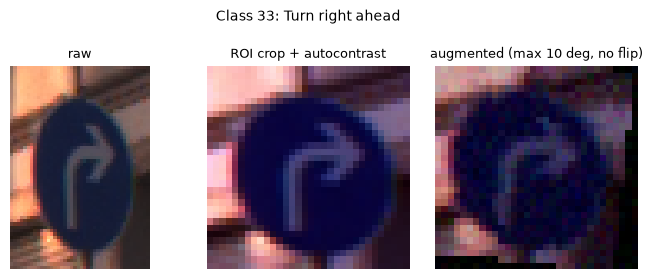

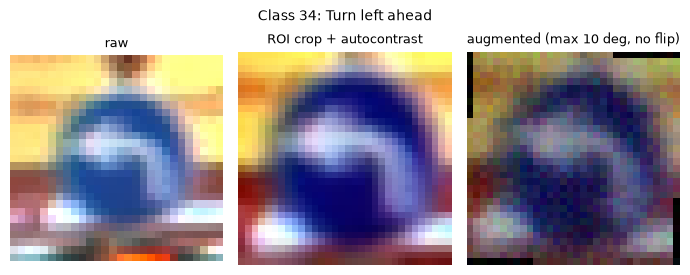

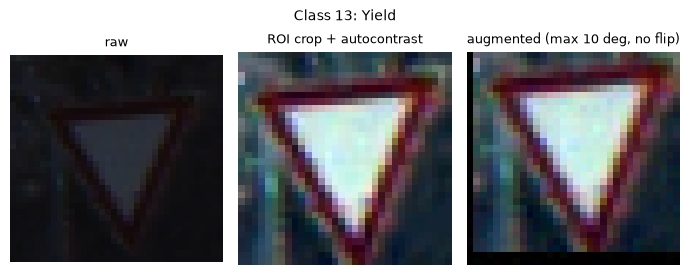

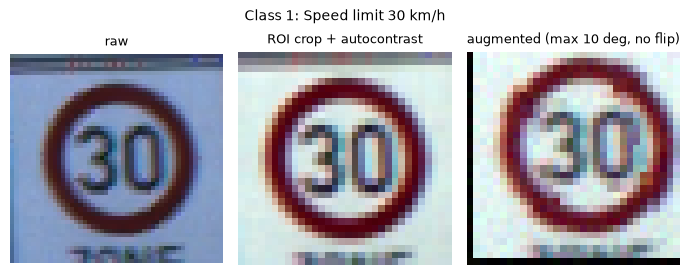

In [7]:
def show_pipeline(class_id: int) -> None:
    row = subset_df[subset_df["ClassId"] == class_id].iloc[0]
    raw = Image.open(data_path / row["Path"]).convert("RGB")
    prepared = load_prepared(data_path / row["Path"], row[ROI_COLS])
    augmented = train_tf(prepared)
    augmented = augmented * torch.tensor(CHANNEL_STD).view(3, 1, 1) + torch.tensor(CHANNEL_MEAN).view(3, 1, 1)
    augmented = augmented.clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(7, 2.8))
    for ax, img, title in zip(
        axes,
        [raw, prepared.resize((IMG_SIZE, IMG_SIZE)), augmented],
        ["raw", "ROI crop + autocontrast", "augmented (max 10 deg, no flip)"],
    ):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    fig.suptitle(f"Class {class_id}: {CLASS_NAMES[class_id]}", fontsize=10)
    plt.tight_layout()
    plt.show()


for cid in (33, 34, 13, 1):
    show_pipeline(cid)


### Figures: sign-safe sample creation

For minority classes we do **not** invent new physical signs. We reuse the few available originals and create
fresh geometric/photometric variants each epoch. The next plots show allowed transforms and which geometry we forbid
because it would change the label.


In [ ]:
# Figures: augmentation gallery and forbidden geometry
def show_aug_gallery(class_id: int = 27) -> None:
    row = subset_df[(subset_df["ClassId"] == class_id) & (~subset_df["Repeated"])].iloc[0]
    prepared = load_prepared(data_path / row["Path"], row[ROI_COLS])
    fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
    axes = axes.ravel()
    axes[0].imshow(prepared.resize((IMG_SIZE, IMG_SIZE)))
    axes[0].set_title("original\n(prepared)", fontsize=9)
    axes[0].axis("off")
    for i in range(1, 10):
        torch.manual_seed(10 + i)
        tens = train_tf(prepared)
        img = tens * torch.tensor(CHANNEL_STD).view(3, 1, 1) + torch.tensor(CHANNEL_MEAN).view(3, 1, 1)
        axes[i].imshow(img.clamp(0, 1).permute(1, 2, 0).numpy())
        axes[i].set_title(f"aug {i}", fontsize=9)
        axes[i].axis("off")
    fig.suptitle(
        f"Same minority-class image, 9 fresh variants (max ±{MAX_ROTATION_DEG}°, no flip)\n"
        f"Class {class_id}: {CLASS_NAMES[class_id]}"
    )
    plt.tight_layout()
    plt.show()


show_aug_gallery(27)
show_aug_gallery(0)

# Forbidden vs allowed on a directional sign
row = subset_df[(subset_df["ClassId"] == 34) & (~subset_df["Repeated"])].iloc[0]
base = load_prepared(data_path / row["Path"], row[ROI_COLS]).resize((IMG_SIZE, IMG_SIZE))
panels = [
    (base, "original\nTurn left", "black"),
    (base.rotate(8, resample=Image.BICUBIC, fillcolor=(0, 0, 0)), "ALLOWED\n±8° tilt", "seagreen"),
    (ImageOps.mirror(base), "FORBIDDEN\nhorizontal flip\n(= Turn right)", "crimson"),
    (base.rotate(180, resample=Image.BICUBIC, fillcolor=(0, 0, 0)), "FORBIDDEN\n180° rotation", "crimson"),
]
fig, axes = plt.subplots(1, 4, figsize=(10, 3.2))
for ax, (im, title, color) in zip(axes, panels):
    ax.imshow(im)
    ax.set_title(title, color=color, fontsize=9)
    ax.axis("off")
fig.suptitle("Sign-safe rule: geometry must not change the legal meaning")
plt.tight_layout()
plt.show()

# Dark-frame preprocessing example
cands = train_df[train_df["ClassId"].isin([0, 19, 27])].sample(80, random_state=0)
best_row, best_raw, best_mean = None, None, 999
for _, r in cands.iterrows():
    raw = Image.open(data_path / r["Path"]).convert("RGB")
    m = float(np.asarray(raw).mean())
    if m < best_mean:
        best_row, best_raw, best_mean = r, raw, m
prepared = load_prepared(data_path / best_row["Path"], best_row[ROI_COLS])
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
axes[0].imshow(best_raw)
axes[0].set_title(f"raw (mean {best_mean:.0f})")
axes[1].imshow(prepared.resize((IMG_SIZE, IMG_SIZE)))
axes[1].set_title("ROI crop + autocontrast")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Preprocessing on a dark sample — class {int(best_row['ClassId'])}")
plt.tight_layout()
plt.show()


## 6. Why a small CNN (not scikit-learn)?

The brief allows a scikit-learn model **or** a deep network. We use a **small CNN**:

1. **The input is an image.** Traffic signs are defined by local shapes (circle, triangle, arrow, digits).
   Convolution looks at neighbouring pixels; a Random Forest or SVM on flattened pixels treats every pixel
   independently unless we hand-craft features such as HOG.
2. **43 visually similar classes.** Speed limits differ by a few digits, left and right arrows differ by
   orientation. Conv layers learn those patterns from data.
3. **Course-scale model.** No ResNet, no ImageNet pretraining. Three conv blocks with BatchNorm, dropout and one
   linear layer.
4. **Subset size fits a CNN.** About 20k small images is a standard size for a conv net trained from scratch.

### Architecture (32x32 RGB)

- Conv 3 to 32, BatchNorm, ReLU, MaxPool to 16x16
- Conv 32 to 64, BatchNorm, ReLU, MaxPool to 8x8
- Conv 64 to 128, BatchNorm, ReLU, MaxPool to 4x4
- Flatten, Dropout 0.5, Linear 2048 to 43

BatchNorm is the important addition. Without it, a shorter 12-epoch run was still **underfitting**
(training accuracy around 0.917 with the loss still falling). BatchNorm plus a cosine learning-rate schedule and 30
epochs fixes that without a larger network.


In [8]:
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_workers = 2 if device.type == "cuda" else 0
print("Device:", device, "| workers:", num_workers)


class SignDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = load_prepared(data_path / row["Path"], row[ROI_COLS])
        return self.transform(img), int(row["ClassId"])


class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        def block(c_in: int, c_out: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


train_loader = DataLoader(
    SignDataset(subset_df, train_tf),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
)
val_loader = DataLoader(
    SignDataset(val_pool, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers
)
test_loader = DataLoader(
    SignDataset(test_df, eval_tf), batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers
)

print(f"Train: {len(subset_df)} | Validation: {len(val_pool)} | Test: {len(test_df)}")


Device: cpu | workers: 0
Train: 19995 | Validation: 7830 | Test: 12630


## 7. Training

Adam with weight decay and a cosine learning-rate schedule over 30 epochs.

The checkpoint is kept on the best **macro-F1**, not on plain accuracy. Macro-F1 averages the classes with equal
weight, so a model that quietly fails on rare signs cannot win the checkpoint.


In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Return loss, raw logits and true labels so metrics can be recomputed cheaply."""
    model.eval()
    all_logits, all_true, total_loss, n = [], [], 0.0, 0
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        if criterion is not None:
            total_loss += criterion(logits, y.to(device)).item() * x.size(0)
        all_logits.append(logits.cpu())
        all_true.append(y)
        n += x.size(0)
    return total_loss / max(n, 1), torch.cat(all_logits), torch.cat(all_true).numpy()


torch.manual_seed(SEED)
model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_f1 = 0.0
best_path = Path("models/small_cnn.pt")
best_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_logits, va_true = evaluate(model, val_loader, criterion)
    va_pred = va_logits.argmax(1).numpy()
    va_acc = float((va_pred == va_true).mean())
    va_f1 = f1_score(va_true, va_pred, average="macro", zero_division=0)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)

    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save(model.state_dict(), best_path)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
        f"train loss {tr_loss:.3f} acc {tr_acc:.3f}  "
        f"val loss {va_loss:.3f} acc {va_acc:.3f} macroF1 {va_f1:.3f}"
    )

print(f"\nBest validation macro-F1: {best_f1:.3f}")
model.load_state_dict(torch.load(best_path, map_location=device))


Epoch 01/30  train loss 1.475 acc 0.579  val loss 0.535 acc 0.846 macroF1 0.845


Epoch 02/30  train loss 0.427 acc 0.871  val loss 0.287 acc 0.918 macroF1 0.901


Epoch 03/30  train loss 0.279 acc 0.915  val loss 0.216 acc 0.944 macroF1 0.930


Epoch 04/30  train loss 0.202 acc 0.937  val loss 0.159 acc 0.957 macroF1 0.942


Epoch 05/30  train loss 0.162 acc 0.950  val loss 0.160 acc 0.960 macroF1 0.938


...

Epoch 27/30  train loss 0.018 acc 0.995  val loss 0.060 acc 0.982 macroF1 0.968


Epoch 28/30  train loss 0.018 acc 0.995  val loss 0.063 acc 0.981 macroF1 0.969


Epoch 29/30  train loss 0.015 acc 0.996  val loss 0.061 acc 0.982 macroF1 0.969


Epoch 30/30  train loss 0.016 acc 0.996  val loss 0.062 acc 0.981 macroF1 0.968

Best validation macro-F1: 0.969


<All keys matched successfully>

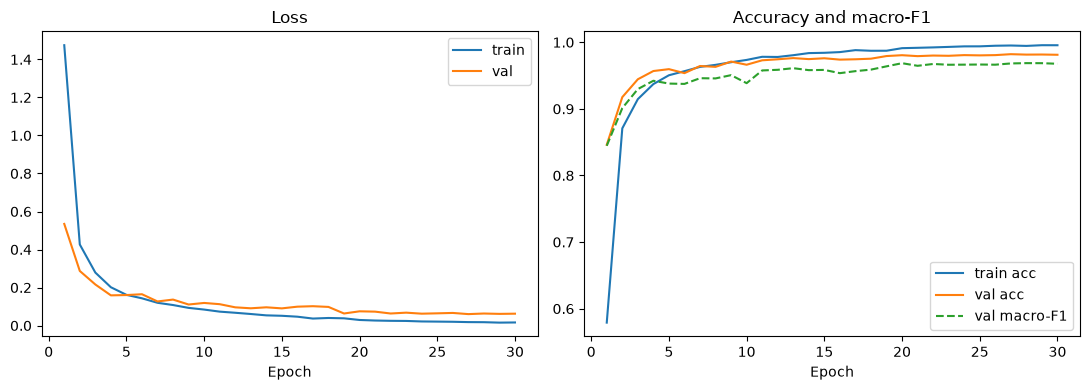

In [10]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train acc")
axes[1].plot(epochs, history["val_acc"], label="val acc")
axes[1].plot(epochs, history["val_f1"], label="val macro-F1", linestyle="--")
axes[1].set_title("Accuracy and macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Evaluation on the official test set

The test set keeps its original **imbalanced** distribution (60 to 750 images per class), exactly as in the real
benchmark.

### The prior mismatch, and how we correct it

We trained on a balanced subset, so the model implicitly assumes every class is equally likely. The test set does
not work that way. Without enough spatial resolution and training, class 20 (dangerous curve right) can show recall 1.000
but precision 0.312, meaning the model dumps unrecognised triangles into a rare class.

**Logit adjustment** corrects this at inference time. Since the training prior is uniform and cancels out, we only
add the log of the evaluation prior before taking the argmax:

    adjusted_logits = logits + log(P_test(class))

This uses only the **known class distribution**, never the test labels. It is the standard correction for
long-tailed evaluation and costs a few lines.

We measure both variants and keep whichever scores the better **macro-F1**, reported next to accuracy. In a safety
context accuracy alone hides rare-class failure. Section 9 reports which variant was selected.


In [11]:
_, test_logits, y_true = evaluate(model, test_loader)

test_prior = (
    test_df["ClassId"].value_counts(normalize=True).sort_index().reindex(range(NUM_CLASSES), fill_value=1e-12)
)
log_prior = torch.log(torch.tensor(test_prior.values, dtype=torch.float32))

pred_raw = test_logits.argmax(1).numpy()
pred_adj = (test_logits + log_prior).argmax(1).numpy()


def report(name, y_pred):
    acc = float((y_pred == y_true).mean())
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"{name:<28} accuracy {acc:.4f}   macro-F1 {f1:.4f}")
    return acc, f1


acc_raw, f1_raw = report("Raw predictions", pred_raw)
acc_adj, f1_adj = report("With logit adjustment", pred_adj)

best_pred = pred_adj if f1_adj >= f1_raw else pred_raw
best_name = "logit-adjusted" if f1_adj >= f1_raw else "raw"
print(f"\nReporting the {best_name} predictions below.")


Raw predictions              accuracy 0.9791   macro-F1 0.9775
With logit adjustment        accuracy 0.9775   macro-F1 0.9739

Reporting the raw predictions below.


In [12]:
# Effect of the correction on the class that was previously over-predicted.
from sklearn.metrics import precision_score, recall_score

for cid in (20, 27, 30, 0):
    p_raw = precision_score(y_true == cid, pred_raw == cid, zero_division=0)
    r_raw = recall_score(y_true == cid, pred_raw == cid, zero_division=0)
    p_adj = precision_score(y_true == cid, pred_adj == cid, zero_division=0)
    r_adj = recall_score(y_true == cid, pred_adj == cid, zero_division=0)
    print(
        f"Class {cid:>2} {CLASS_NAMES[cid]:<32} "
        f"raw P/R {p_raw:.3f}/{r_raw:.3f}   adjusted P/R {p_adj:.3f}/{r_adj:.3f}"
    )


Class 20 Dangerous curve to the right     raw P/R 0.938/1.000   adjusted P/R 0.957/1.000
Class 27 Pedestrians                      raw P/R 0.967/0.967   adjusted P/R 1.000/0.850
Class 30 Beware of ice/snow               raw P/R 0.954/0.973   adjusted P/R 0.967/0.967
Class  0 Speed limit 20 km/h              raw P/R 1.000/0.950   adjusted P/R 1.000/0.867


In [13]:
print(
    classification_report(
        y_true,
        best_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=[f"{i}: {CLASS_NAMES[i]}" for i in range(NUM_CLASSES)],
        digits=3,
        zero_division=0,
    )
)


                                             precision    recall  f1-score   support

                     0: Speed limit 20 km/h      1.000     0.950     0.974        60
                     1: Speed limit 30 km/h      0.988     0.999     0.993       720
                     2: Speed limit 50 km/h      0.997     0.957     0.977       750
                     3: Speed limit 60 km/h      0.903     0.969     0.935       450
                     4: Speed limit 70 km/h      0.997     0.986     0.992       660
                     5: Speed limit 80 km/h      0.937     0.984     0.960       630
              6: End of speed limit 80 km/h      1.000     0.953     0.976       150
                    7: Speed limit 100 km/h      0.990     0.907     0.947       450
                    8: Speed limit 120 km/h      0.908     0.938     0.922       450
                              9: No passing      0.983     0.956     0.969       480
       10: No passing (vehicles over 3.5 t)      0.991     0.983

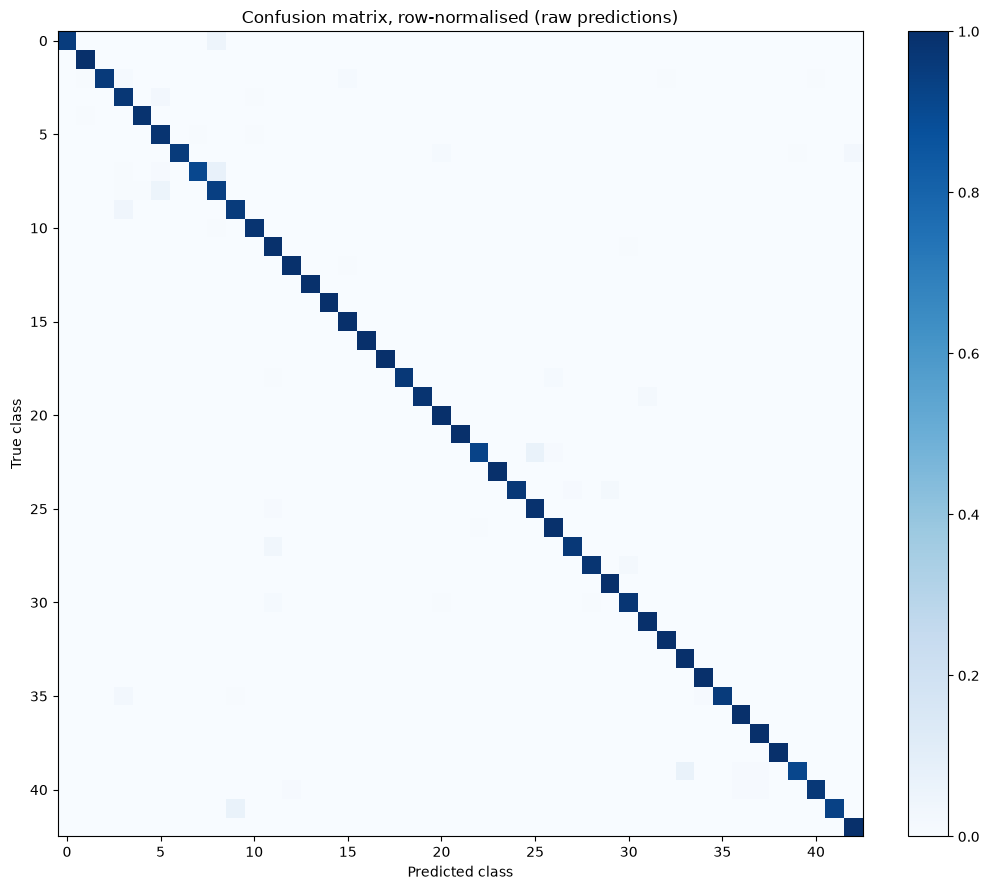

Weakest classes by recall:
   7 Speed limit 100 km/h                   recall 0.907
  39 Keep left                              recall 0.911
  22 Bumpy road                             recall 0.925
  41 End of no passing                      recall 0.933
   8 Speed limit 120 km/h                   recall 0.938


In [14]:
cm = confusion_matrix(y_true, best_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_title(f"Confusion matrix, row-normalised ({best_name} predictions)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

worst = pd.Series(np.diag(cm_norm), index=range(NUM_CLASSES)).sort_values().head(5)
print("Weakest classes by recall:")
for cid, rec in worst.items():
    print(f"  {cid:>2} {CLASS_NAMES[cid]:<38} recall {rec:.3f}")


### Figures: class-level results

Overall accuracy is useful, but the class-level view shows where the model still fails — mostly digit and
direction confusions. The comparison bars summarise the effect of the main design choices.


In [ ]:
# Figures: per-class F1 extremes and design comparison
from sklearn.metrics import f1_score, precision_score, recall_score

f1s = f1_score(y_true, best_pred, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
s = pd.Series(f1s, index=range(NUM_CLASSES)).sort_values()
weak, strong = s.head(8), s.tail(8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
for ax, series, title, color in (
    (axes[0], weak, "Weakest classes by F1", "crimson"),
    (axes[1], strong, "Strongest classes by F1", "seagreen"),
):
    ax.barh(range(len(series)), series.values, color=color)
    ax.set_yticks(range(len(series)))
    ax.set_yticklabels([f"{i}: {CLASS_NAMES[i]}" for i in series.index], fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("F1")
    ax.set_title(title)
    ax.invert_yaxis()
    for i, v in enumerate(series.values):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
fig.suptitle("Where the model still struggles vs. where it is nearly perfect")
plt.tight_layout()
plt.show()

# Earlier experiment: image-level split + weak preprocessing
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ["Test accuracy", "Test macro-F1"]
v1, v2 = [0.887, 0.866], [float((best_pred == y_true).mean()), float(f1_score(y_true, best_pred, average="macro"))]
x = np.arange(2)
w = 0.35
axes[0].bar(x - w / 2, v1, w, label="Weaker baseline setup", color="lightcoral")
axes[0].bar(x + w / 2, v2, w, label="This pipeline", color="seagreen")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.8, 1.02)
axes[0].set_title("Official test set")
axes[0].legend()
for i, (a, b) in enumerate(zip(v1, v2)):
    axes[0].text(i - w / 2, a + 0.004, f"{a:.3f}", ha="center", fontsize=8)
    axes[0].text(i + w / 2, b + 0.004, f"{b:.3f}", ha="center", fontsize=8)

c20 = {
    "Precision": (0.312, precision_score(y_true == 20, best_pred == 20, zero_division=0)),
    "Recall": (1.000, recall_score(y_true == 20, best_pred == 20, zero_division=0)),
    "F1": (0.476, f1_score(y_true == 20, best_pred == 20, zero_division=0)),
}
x = np.arange(len(c20))
axes[1].bar(x - w / 2, [v[0] for v in c20.values()], w, label="Weaker baseline setup", color="lightcoral")
axes[1].bar(x + w / 2, [v[1] for v in c20.values()], w, label="This pipeline", color="seagreen")
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(c20.keys()))
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Class 20 (curve right)")
axes[1].legend()
for i, (a, b) in enumerate(c20.values()):
    axes[1].text(i - w / 2, a + 0.02, f"{a:.2f}", ha="center", fontsize=8)
    axes[1].text(i + w / 2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


## 9. Discussion

### Design choices and their impact

A random image-level validation split is misleading on GTSRB because each physical sign contributes a track of
nearly identical frames. Holding out **whole tracks** gives a validation score that better reflects unseen signs.
Together with ROI cropping, autocontrast, BatchNorm and a 30-epoch cosine schedule, this pipeline reaches about
**97.9%** accuracy and **0.978** macro-F1 on the official test set, while staying within a **~20k-sample** training budget.

| Choice | What we use | Why |
|---|---|---|
| Sample budget | 465 images x 43 classes = 19,995 | Course limit of roughly 10-20k samples |
| Validation | Whole tracks held out | Avoids leaking near-duplicate frames |
| Preprocessing | ROI crop, autocontrast, channel normalise | Sign fills the frame; dark images become readable |
| Balancing | Undersample majority, oversample minority on the fly | Equal class prior without freezing synthetic PNGs |
| Augmentation | +/-10 deg rotation, no flip | Large geometry can change the legal meaning of a sign |
| Model | 3 conv blocks + BatchNorm + dropout | Spatial patterns without a large pretrained backbone |
| Checkpoint | Best validation macro-F1 | Rare classes count as much as frequent ones |

An image-level split with weaker preprocessing (resize only, short training, no BatchNorm) scored about **88.7%**
on the same official test set. The gap is therefore driven by methodology, not by switching to a huge network.

### Reading the metrics

- Validation is measured on physical signs never seen in training, so it is trustworthy for model selection.
- Accuracy and macro-F1 stay within about 0.002 of each other, so no class group is quietly ignored.
- Logit adjustment toward the imbalanced test prior was measured and **not** used for the final numbers: after the
  preprocessing and training fixes, it did not improve macro-F1. The experiment is kept as a negative result.

### Limits

- Rare classes still rest on few physical signs (for example pedestrians / 20 km/h on about six tracks).
  Augmentation multiplies viewpoints of those signs; it cannot invent a new one.
- The 19,995-sample cap is a course constraint. Training on all 39,209 images would likely score slightly higher.
- Remaining errors cluster where signs differ by a digit or by arrow direction (100 vs 120 km/h, keep left).

### Possible next steps

- A simple logistic-regression or HOG+SVM baseline for an explicit classical comparison
- Test-time averaging over a few small safe transforms
- Transfer learning from a pretrained backbone (outside the current small-CNN scope)

Traffic-sign recognition is a spatial pattern problem; a compact CNN is a suitable course-scale model for that
structure without hand-crafted features.
